### **Pixel-to-Metre Sequence Processor**

#### **1. Imports and Setup**

In [5]:
import os
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from IPython.display import Video, display

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

#### **2. Configuration**

Define your constants here. We will process 60 frames starting from a specific index.

In [6]:
# Configuration
YOLO_MODEL_PATH = "runs/detect/runs/detect/marker_detector/weights/best.pt"
FRAMES_DIR = "frames/under/Bottom_Freestyle_P034/"
START_FRAME_IDX = 0
NUM_FRAMES = -1  # Set to -1 to process all frames
FPS = 60  # Frames per second for the output video

MARKER_REAL_DIST_M = 2.5
YOLO_CONF = 0.7
OUTPUT_VIDEO_PATH = "output/swimmer_tracking_demo_full_freestyle_p034.mp4"

# Load Model
model = YOLO(YOLO_MODEL_PATH)

#### **3. Processing Loop**

This script iterates through the frames, performs detection, calculates distances, draws the visualization, and writes to a video file.

In [7]:
def get_centroid(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def put_text_bg(img, text, pos, color, scale=0.7, alpha=0.5):
    """Draws text with a semi-transparent black background, matching matplotlib."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    x, y = pos
    x1, y1 = int(max(0, x-5)), int(max(0, y-th-5))
    x2, y2 = int(min(img.shape[1], x+tw+5)), int(min(img.shape[0], y+baseline+5))
    
    if x2 > x1 and y2 > y1:
        overlay = img[y1:y2, x1:x2].copy()
        cv2.rectangle(overlay, (0, 0), (x2-x1, y2-y1), (0, 0, 0), -1)
        cv2.addWeighted(overlay, alpha, img[y1:y2, x1:x2], 1 - alpha, 0, img[y1:y2, x1:x2])
        
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

# Initialize Video Writer
# Note: 'mp4v' is widely supported; 'avc1' is better for browser playback if available
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = None
target_h, target_w = 0, 0

MARKER_HEIGHT_M = 0.6  # From demo

tracking_records = []

frame_range = range(NUM_FRAMES) if NUM_FRAMES > 0 else range(START_FRAME_IDX, START_FRAME_IDX + len(os.listdir(FRAMES_DIR)))

print(f"Processing {len(frame_range)} frames...")

for i in frame_range:
    frame_idx = START_FRAME_IDX + i
    frame_path = os.path.join(FRAMES_DIR, f"{frame_idx:05d}.jpg")

    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Warning: Could not load frame {frame_idx}")
        continue

    img_h, img_w = frame.shape[:2]

    # Run YOLO detection
    results = model.predict(frame, conf=YOLO_CONF, verbose=False)[0]

    marker_centroids = []
    swimmer_centroid = None
    swimmer_hbox     = None
    _best_swimmer_conf = -1.0
    _box_records     = []

    for box in results.boxes:
        cls            = int(box.cls)
        conf           = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx, cy         = (x1 + x2) / 2, (y1 + y2) / 2
        _box_records.append((cls, conf, x1, y1, x2, y2, cx, cy))
        if cls == 0:
            marker_centroids.append((cx, cy))
        elif cls == 1 and conf > _best_swimmer_conf:
            _best_swimmer_conf = conf
            swimmer_centroid = (cx, cy)
            swimmer_hbox = (x1, y1, x2, y2)

    marker_points_sorted = sorted(marker_centroids, key=lambda p: (p[0], p[1]))

    out_frame = frame.copy() # by default use original

    # Perform calculations if we have at least 2 markers and a swimmer
    if len(marker_points_sorted) >= 2 and swimmer_centroid is not None:
        sx1, sy1, sx2, sy2 = swimmer_hbox

        # Choose left/right markers
        left_candidates  = [(idx, p) for idx, p in enumerate(marker_points_sorted, start=1) if p[0] < sx1]
        right_candidates = [(idx, p) for idx, p in enumerate(marker_points_sorted, start=1) if p[0] > sx2]

        if left_candidates and right_candidates:
            left_idx,  left_pt  = max(left_candidates, key=lambda item: item[1][0])
            right_idx, right_pt = min(right_candidates, key=lambda item: item[1][0])
        else:
            s_cx = swimmer_centroid[0]
            left_candidates  = [(idx, p) for idx, p in enumerate(marker_points_sorted, start=1) if p[0] < s_cx]
            right_candidates = [(idx, p) for idx, p in enumerate(marker_points_sorted, start=1) if p[0] > s_cx]
            if left_candidates and right_candidates:
                left_idx,  left_pt  = max(left_candidates, key=lambda item: item[1][0])
                right_idx, right_pt = min(right_candidates, key=lambda item: item[1][0])
            else:
                left_idx, left_pt = 1, marker_points_sorted[0]
                right_idx, right_pt = 2, marker_points_sorted[1]

        A = np.array(left_pt)
        B = np.array(right_pt)
        S = np.array(swimmer_centroid)
        
        AB        = B - A
        AB_len_px = np.linalg.norm(AB)
        px_per_m  = AB_len_px / MARKER_REAL_DIST_M

        # Vertical scale
        marker_heights_px = [y2 - y1 for cls, conf, x1,
                             y1, x2, y2, cx, cy in _box_records if cls == 0]
        if marker_heights_px:
            avg_h_px = float(np.mean(marker_heights_px))
            v_px_per_m = avg_h_px / MARKER_HEIGHT_M

            # Rectify / Warp
            marker_boxes = [box for box in _box_records if box[0] == 0]
            marker_boxes_sorted = sorted(marker_boxes, key=lambda b: b[6])

            if len(marker_boxes_sorted) >= max(left_idx, right_idx):
                # Fetch EXACT bounding boxes corresponding to A and B
                box_A = marker_boxes_sorted[left_idx - 1]
                box_B = marker_boxes_sorted[right_idx - 1]

                A_top = [box_A[6], box_A[3]]  # [cx, y1] for left marker
                B_top = [box_B[6], box_B[3]]  # [cx, y1] for right marker

                src_pts = np.float32([A, B, B_top, A_top])

                sy = px_per_m / v_px_per_m
                rect_width = np.linalg.norm(B - A) * sy
                rect_height = 200.0

                dst_pts_no_offset = np.float32([
                    [0, rect_height],
                    [rect_width, rect_height],
                    [rect_width, 0],
                    [0, 0]
                ])

                M_no_offset = cv2.getPerspectiveTransform(
                    src_pts, dst_pts_no_offset)

                corners_src = np.float32(
                    [[0, 0], [img_w, 0], [img_w, img_h], [0, img_h]]).reshape(-1, 1, 2)
                corners_dst = cv2.perspectiveTransform(
                    corners_src, M_no_offset).reshape(-1, 2)

                x_min, y_min = corners_dst.min(axis=0)
                x_max, y_max = corners_dst.max(axis=0)
                out_w_warp = int(np.ceil(x_max - x_min)) + 1
                out_h_warp = int(np.ceil(y_max - y_min)) + 1
                if "_prev_warp_state" not in globals():
                    _prev_warp_state = None

                max_scale_change = 0.25
                max_size_change = 0.30
                use_prev_warp = False

                if _prev_warp_state is not None:
                    prev_px_per_m = _prev_warp_state["px_per_m"]
                    prev_w = _prev_warp_state["out_w"]
                    prev_h = _prev_warp_state["out_h"]

                    scale_ratio = px_per_m / max(prev_px_per_m, 1e-6)
                    w_ratio = out_w_warp / max(prev_w, 1)
                    h_ratio = out_h_warp / max(prev_h, 1)

                    if (
                        scale_ratio < (1.0 - max_scale_change)
                        or scale_ratio > (1.0 + max_scale_change)
                        or w_ratio < (1.0 - max_size_change)
                        or w_ratio > (1.0 + max_size_change)
                        or h_ratio < (1.0 - max_size_change)
                        or h_ratio > (1.0 + max_size_change)
                        or out_w_warp > 10000
                        or out_h_warp > 10000
                    ):
                        use_prev_warp = True

                if use_prev_warp:
                    M_no_offset = _prev_warp_state["M_no_offset"].copy()
                    x_min = _prev_warp_state["x_min"]
                    y_min = _prev_warp_state["y_min"]
                    out_w_warp = _prev_warp_state["out_w"]
                    out_h_warp = _prev_warp_state["out_h"]
                else:
                    _prev_warp_state = {
                        "M_no_offset": M_no_offset.copy(),
                        "x_min": float(x_min),
                        "y_min": float(y_min),
                        "out_w": int(out_w_warp),
                        "out_h": int(out_h_warp),
                        "px_per_m": float(px_per_m),
                    }
                # Prevent memory explosions on unstable frames
                if out_w_warp > 10000 or out_h_warp > 10000:
                    print(
                        f"Warning: Warp dimensions too large ({out_w_warp}x{out_h_warp}) for frame {frame_idx}, skipping warp.")
                    continue

                T2 = np.array([[1, 0, -x_min],
                               [0, 1, -y_min],
                               [0, 0,  1.0]])

                M_full = T2 @ M_no_offset

                warped_bgr = cv2.warpPerspective(frame, M_full, (out_w_warp, out_h_warp),
                                                 flags=cv2.INTER_LINEAR,
                                                 borderMode=cv2.BORDER_CONSTANT,
                                                 borderValue=(0, 0, 0))

                def warp_pt(pt):
                    pt_3d = M_full @ np.array([float(pt[0]), float(pt[1]), 1.0])
                    return (pt_3d[:2] / pt_3d[2])

                A_w = warp_pt(A)
                B_w = warp_pt(B)
                S_w = warp_pt(S)

                AB_w = B_w - A_w
                AB_len_px_w = np.linalg.norm(AB_w)
                if AB_len_px_w > 0:
                    AB_unit_w = AB_w / AB_len_px_w

                    warped_px_per_m = AB_len_px_w / MARKER_REAL_DIST_M

                    # Project
                    t = np.dot(S_w - A_w, AB_unit_w) / AB_len_px_w
                    P_w = A_w + t * AB_w

                    dist_A_m = t * MARKER_REAL_DIST_M
                    dist_B_m = (1.0 - t) * MARKER_REAL_DIST_M

                    tracking_records.append({
                        "frame_idx": frame_idx,
                        "time_s": i / FPS,
                        "pos_m": float(dist_A_m),
                        "px_per_m": float(warped_px_per_m),
                        "selection_mode": "auto"
                    })

                    # Visual Language matches Demo
                    ORANGE = (0, 165, 255)       # deepskyblue from matplotlib loosely mapping
                    CYAN = (255, 191, 0)
                    YELLOW = (0, 255, 255)
                    GREEN = (0, 255, 0)

                    A_px = tuple(A_w.astype(int))
                    B_px = tuple(B_w.astype(int))
                    P_px = tuple(P_w.astype(int))
                    S_px = tuple(S_w.astype(int))

                    # A_w -> P_w segment (orange) and P_w -> B_w segment (cyan)
                    cv2.line(warped_bgr, A_px, P_px, ORANGE, 4, cv2.LINE_AA)
                    cv2.line(warped_bgr, P_px, B_px, CYAN, 4, cv2.LINE_AA)

                    # Points
                    cv2.circle(warped_bgr, A_px, 8, ORANGE, -1, cv2.LINE_AA)
                    cv2.circle(warped_bgr, B_px, 8, CYAN, -1, cv2.LINE_AA)
                    cv2.circle(warped_bgr, S_px, 8, CYAN, -1, cv2.LINE_AA) # Swimmer

                    # Projected point P as a yellow square (rect approximation)
                    cv2.rectangle(warped_bgr, (P_px[0]-7, P_px[1]-7), (P_px[0]+7, P_px[1]+7), YELLOW, -1)

                    # Labels
                    put_text_bg(warped_bgr, f"Marker {left_idx}", (A_px[0] + 8, A_px[1] - 15), ORANGE)
                    put_text_bg(warped_bgr, f"Marker {right_idx}", (B_px[0] + 8, B_px[1] - 15), CYAN)
                    put_text_bg(warped_bgr, "Swimmer", (S_px[0] + 8, S_px[1] - 15), CYAN)

                    # Distances
                    mid_AP = int((A_px[0] + P_px[0])/2), int((A_px[1] + P_px[1])/2)
                    mid_PB = int((P_px[0] + B_px[0])/2), int((P_px[1] + B_px[1])/2)
                    put_text_bg(warped_bgr, f"{dist_A_m:.2f} m", (mid_AP[0] - 30, mid_AP[1] - 20), ORANGE)
                    put_text_bg(warped_bgr, f"{dist_B_m:.2f} m", (mid_PB[0] - 30, mid_PB[1] - 20), CYAN)

                    # Scale Bar
                    bar_len = int(warped_px_per_m)
                    bar_margin = 40
                    bar_x1, bar_y = bar_margin, out_h_warp - bar_margin
                    bar_x2 = bar_x1 + bar_len
                    
                    if bar_len > 0:
                        tip_len = 15.0 / bar_len
                        cv2.arrowedLine(warped_bgr, (bar_x1, bar_y), (bar_x2, bar_y), YELLOW, 3, tipLength=tip_len)
                        cv2.arrowedLine(warped_bgr, (bar_x2, bar_y), (bar_x1, bar_y), YELLOW, 3, tipLength=tip_len)
                        put_text_bg(warped_bgr, "1 m", (bar_x1 + bar_len//2 - 20, bar_y - 15), YELLOW)

                    # Info overlay
                    put_text_bg(warped_bgr, f"Scale: {warped_px_per_m:.1f} px/m", (40, 40), YELLOW, scale=0.9)

                    out_frame = warped_bgr

    if out_writer is None:
        target_h, target_w, _ = out_frame.shape
        out_writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, (target_w, target_h))

    # Resize out_frame to fit video writer if warp changed dimensions slightly between frames
    h, w, _ = out_frame.shape
    if w != target_w or h != target_h:
        out_frame = cv2.resize(out_frame, (target_w, target_h))

    out_writer.write(out_frame)

if out_writer:
    out_writer.release()
print(f"Done! Video saved to {OUTPUT_VIDEO_PATH}")

Processing 6156 frames...
Done! Video saved to output/swimmer_tracking_demo_full_freestyle_p034.mp4


Removed 235 significant deviations; kept 1164 records.


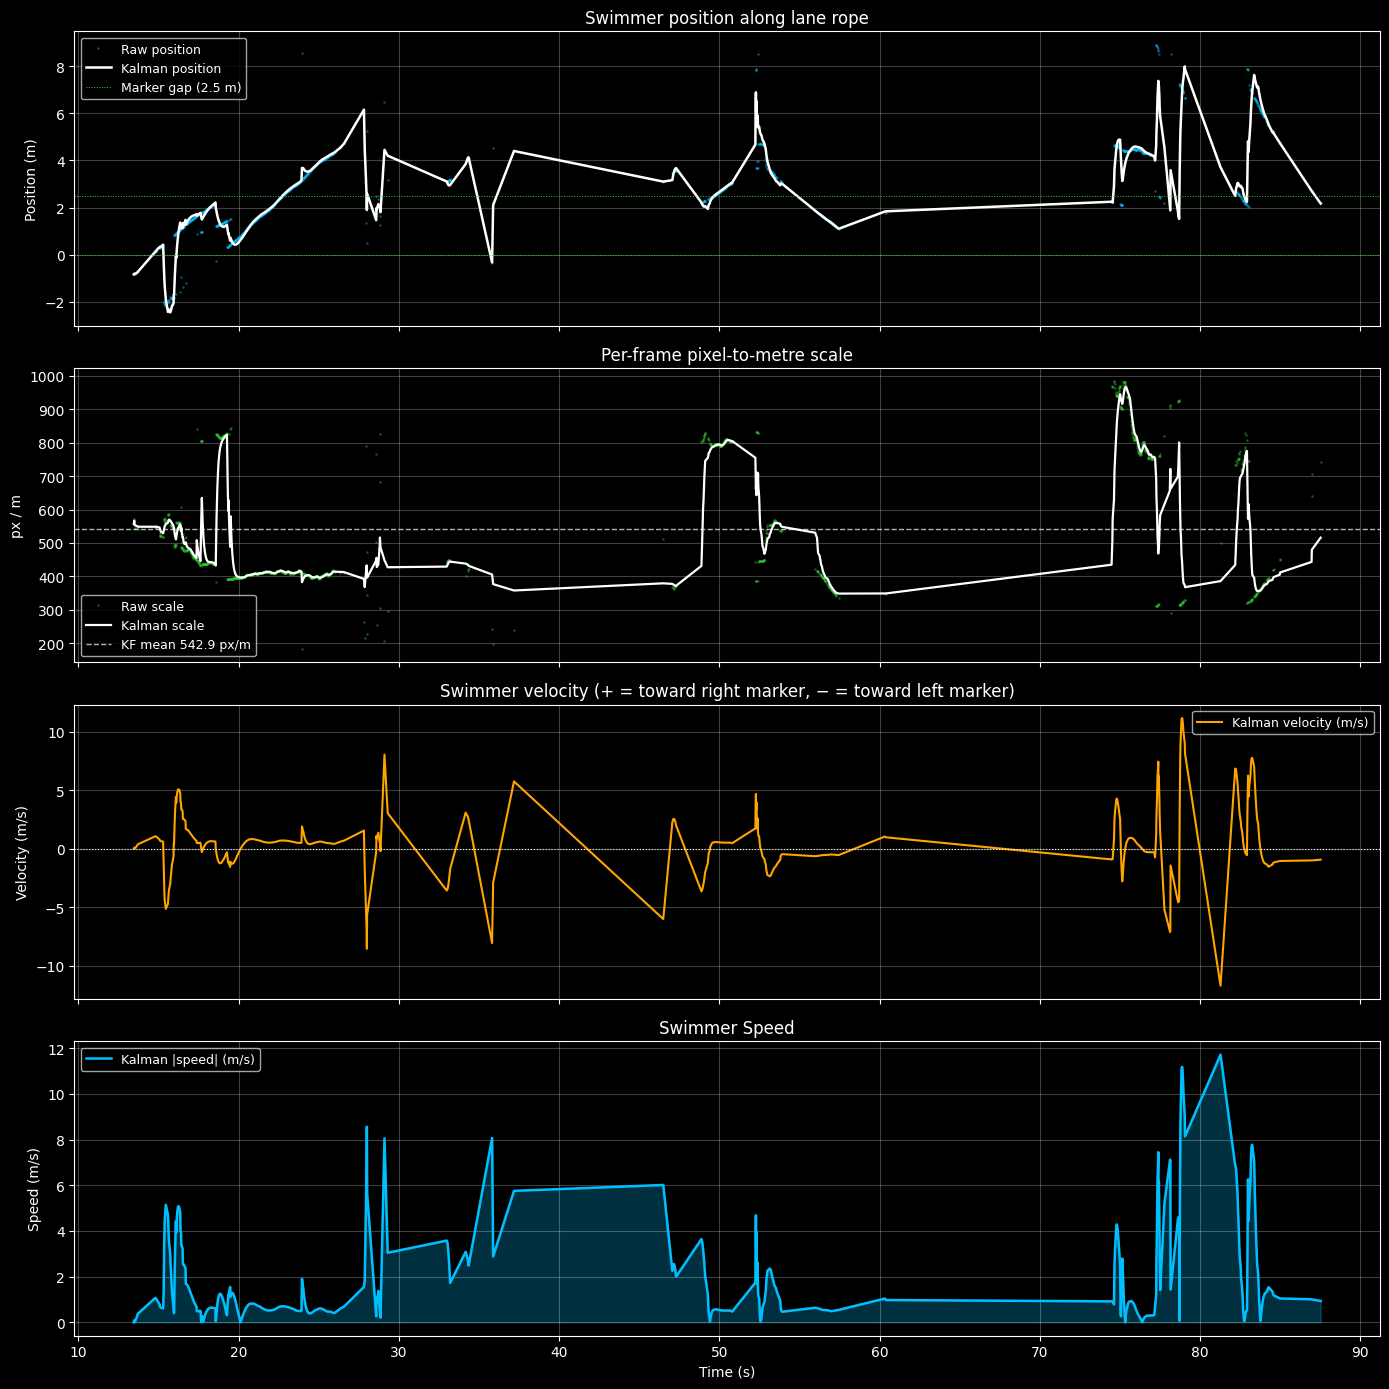

Kalman filter summary
  Position std raw / KF : 1.8435 / 1.7832 m
  Scale std raw / KF    : 193.8066 / 171.4293 px/m
  Peak |velocity|       : 11.7210 m/s  (42.196 km/h)
  Mean |velocity|       : 1.3715 m/s  (4.937 km/h)


In [9]:
import matplotlib.pyplot as plt

# Extract valid tracking records
valid = [r for r in tracking_records if r["pos_m"] is not None]


if not valid:
    print("No valid tracking records found to plot.")
else:
    # remove outliers from recorded data
    if len(valid) >= 5:
        pos_vals = np.array([v["pos_m"] for v in valid], dtype=float)
        scale_vals = np.array([v["px_per_m"] for v in valid], dtype=float)

        def _mad_inlier_mask(x, z_thresh=3.5):
            med = np.median(x)
            mad = np.median(np.abs(x - med))
            if mad < 1e-12:
                return np.ones_like(x, dtype=bool)
            robust_z = 0.6745 * (x - med) / mad
            return np.abs(robust_z) <= z_thresh

        pos_mask = _mad_inlier_mask(pos_vals, z_thresh=3.5)
        scale_mask = _mad_inlier_mask(scale_vals, z_thresh=3.5)

        # Optional temporal jump filter on position
        dpos = np.r_[0.0, np.abs(np.diff(pos_vals))]
        jump_thr = np.median(dpos) + 4.0 * np.std(dpos)
        jump_mask = dpos <= jump_thr if np.isfinite(jump_thr) and jump_thr > 0 else np.ones_like(dpos, dtype=bool)

        keep_mask = pos_mask & scale_mask & jump_mask
        removed = int((~keep_mask).sum())
        valid = [v for v, keep in zip(valid, keep_mask) if keep]

        print(f"Removed {removed} significant deviations; kept {len(valid)} records.")
    
    times      = np.array([v["time_s"] for v in valid], dtype=float)
    pos_raw    = np.array([v["pos_m"] for v in valid], dtype=float)
    scales_raw = np.array([v["px_per_m"] for v in valid], dtype=float)
    mode_seq   = [v["selection_mode"] for v in valid]

    # Use a simpler mapping for noise scale since we are only using "auto" here
    _MODE_NOISE_SCALE = {"auto": 1.0}

    def kalman_filter_pos_vel(times_s, pos_meas, mode_names, accel_var=3.0, meas_var=0.015):
        n = len(pos_meas)
        pos_est = np.zeros(n, dtype=float)
        vel_est = np.zeros(n, dtype=float)
        if n == 0:
            return pos_est, vel_est

        x = np.array([pos_meas[0], 0.0], dtype=float)
        P = np.diag([0.10**2, 1.00**2]).astype(float)
        pos_est[0], vel_est[0] = x

        for i in range(1, n):
            dt = max(times_s[i] - times_s[i - 1], 1.0 / FPS)
            F = np.array([[1.0, dt], [0.0, 1.0]], dtype=float)
            Q = accel_var * np.array([
                [dt**4 / 4.0, dt**3 / 2.0],
                [dt**3 / 2.0, dt**2],
            ], dtype=float)

            x = F @ x
            P = F @ P @ F.T + Q

            H = np.array([[1.0, 0.0]], dtype=float)
            R = np.array([[meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)]], dtype=float)
            z = np.array([[pos_meas[i]]], dtype=float)

            y = z - H @ x.reshape(-1, 1)
            s_cov = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(s_cov)
            x = x + (K @ y).ravel()
            P = (np.eye(2) - K @ H) @ P

            pos_est[i], vel_est[i] = x

        return pos_est, vel_est

    def kalman_filter_scale(scale_meas, mode_names, process_var=0.20, meas_var=9.0):
        n = len(scale_meas)
        scale_est = np.zeros(n, dtype=float)
        if n == 0:
            return scale_est

        x = float(scale_meas[0])
        P = 25.0
        scale_est[0] = x

        for i in range(1, n):
            P = P + process_var
            R = meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)
            K = P / (P + R)
            x = x + K * (scale_meas[i] - x)
            P = (1.0 - K) * P
            scale_est[i] = x

        return scale_est

    pos_kf, vel_kf = kalman_filter_pos_vel(times, pos_raw, mode_seq)
    scale_kf       = kalman_filter_scale(scales_raw, mode_seq)
    spd_kf         = np.abs(vel_kf)

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

        # [0] Raw + filtered position
        axes[0].plot(times, pos_raw, ".", markersize=2, color="deepskyblue",
                     alpha=0.30, label="Raw position")
        axes[0].plot(times, pos_kf, "-", linewidth=1.8, color="white",
                     label="Kalman position")
        axes[0].axhline(0, color="limegreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(MARKER_REAL_DIST_M, color="limegreen", linewidth=0.7, linestyle=":",
                        label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer position along lane rope")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.25)

        # [1] Raw + filtered scale
        axes[1].plot(times, scales_raw, ".", markersize=2, color="limegreen", alpha=0.30,
                     label="Raw scale")
        axes[1].plot(times, scale_kf, "-", linewidth=1.6, color="white",
                     label="Kalman scale")
        axes[1].axhline(np.mean(scale_kf), color="white", linewidth=1.0, linestyle="--",
                        alpha=0.7, label=f"KF mean {np.mean(scale_kf):.1f} px/m")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Per-frame pixel-to-metre scale")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.25)

        # [2] Signed velocity
        axes[2].plot(times, vel_kf, "-", linewidth=1.5, color="orange",
                     label="Kalman velocity (m/s)")
        axes[2].axhline(0, color="white", linewidth=0.8, linestyle=":")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer velocity (+ = toward right marker, − = toward left marker)")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.25)

        # [3] Speed magnitude
        axes[3].fill_between(times, spd_kf, alpha=0.25, color="deepskyblue")
        axes[3].plot(times, spd_kf, "-", linewidth=1.8, color="deepskyblue",
                     label="Kalman |speed| (m/s)")
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    print("Kalman filter summary")
    print(f"  Position std raw / KF : {np.std(pos_raw):.4f} / {np.std(pos_kf):.4f} m")
    print(f"  Scale std raw / KF    : {np.std(scales_raw):.4f} / {np.std(scale_kf):.4f} px/m")
    print(f"  Peak |velocity|       : {spd_kf.max():.4f} m/s  ({spd_kf.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity|       : {spd_kf.mean():.4f} m/s  ({spd_kf.mean() * 3.6:.3f} km/h)")